# Week 6: Polynomial Regression, Overfitting & Regularization

## Student Practice Notebook

**Name:** Sajal Porey <br>
**Roll Number:** AP24110011895 <br>
**Date:** 14-9-2026

## Learning Objectives

After completing this lab, you will be able to:

- Engineer polynomial features and fit non-linear relationships with linear regression
- Recognize underfitting and overfitting from train vs. test performance
- Explain the bias-variance tradeoff in your own words
- Apply Ridge (L2), Lasso (L1), and ElasticNet regularization to fix an overfit model
- Explain why Lasso can zero out weights entirely while Ridge only shrinks them

### Why this week matters
Last week's linear model assumed a straight-line relationship. Real relationships often curve. This week you'll see what happens when a model gets too flexible — and how regularization reins it back in. This is the single most useful skill for making any model in your capstone project generalize, not just memorize.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline
np.random.seed(1)


## Part 1 — Polynomial Regression

### 1.1 Demo: a curved relationship


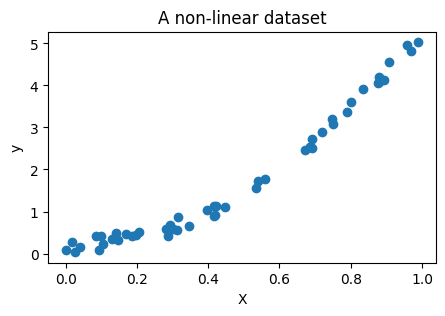

In [2]:
X_demo = np.random.rand(50, 1)
y_demo = (
    0.7 * X_demo ** 5 - 2.1 * X_demo ** 4 + 2.7 * X_demo ** 3
    + 3.5 * X_demo ** 2 + 0.3 * X_demo + 0.4 * np.random.rand(50, 1)
)

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo)
plt.xlabel('X')
plt.ylabel('y')
plt.title('A non-linear dataset')
plt.show()


### 1.2 Fitting a plain (degree-1) line — does it work?

R2: 0.9345996128366808


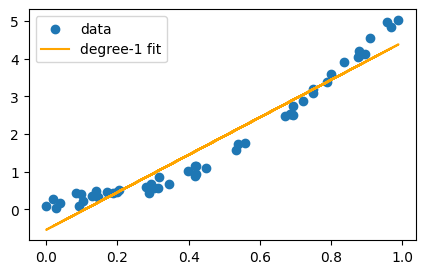

In [3]:
lin = LinearRegression()
lin.fit(X_demo, y_demo)
pred = lin.predict(X_demo)

print('R2:', lin.score(X_demo, y_demo))

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo, label='data')
plt.plot(X_demo, pred, color='orange', label='degree-1 fit')
plt.legend()
plt.show()


**Predict, then think:** before running the next cell, guess — will a degree-2 polynomial fit noticeably better? Why or why not?

*Your answer:* Yes, a degree 2 polynomial will fit noticeably better because the underlying relationship has clear quadratic curvature over the input domain from 0 to 1. A straight degree 1 line cannot follow this curve and underfits the dataset, while a degree 2 parabola bends to trace the curvature accurately.


### Student Practice — fit a degree-3 polynomial

Use `PolynomialFeatures(degree=3, include_bias=False)` to transform `X_demo`, then fit a `LinearRegression` on the transformed features. Plot the result like the demo above (tip: sort `X_demo` before plotting the line, or the plot will look jagged).


R2: 0.994924691754525


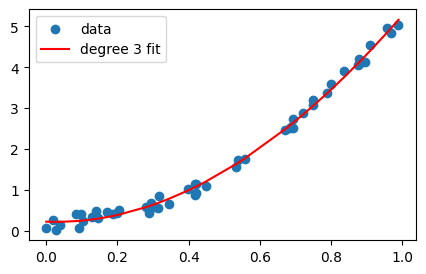

In [4]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_demo_poly3 = poly3.fit_transform(X_demo)

model3 = LinearRegression()
model3.fit(X_demo_poly3, y_demo)

print('R2:', model3.score(X_demo_poly3, y_demo))

sort_indices = np.argsort(X_demo[:, 0])
X_demo_sorted = X_demo[sort_indices]
pred3_sorted = model3.predict(poly3.transform(X_demo_sorted))

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo, label='data')
plt.plot(X_demo_sorted, pred3_sorted, color='red', label='degree 3 fit')
plt.legend()
plt.show()


## Part 2 — The Bias-Variance Tradeoff

We'll sweep polynomial degree from 1 to 25 on a train/test split, and watch what happens to train vs. test performance.


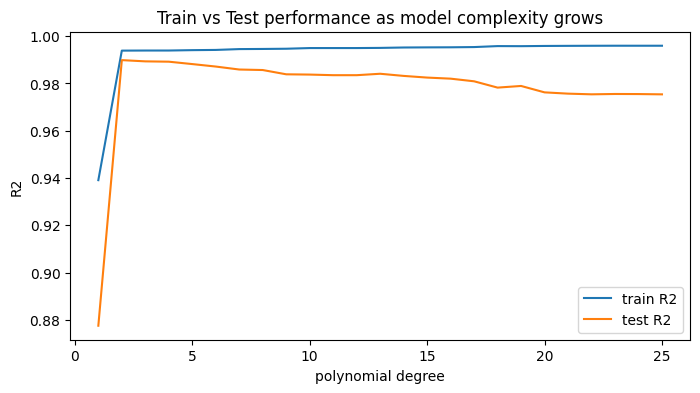

In [5]:
np.random.seed(1)
X_bv = np.random.rand(100, 1)
y_bv = (
    0.7 * X_bv ** 5 - 2.1 * X_bv ** 4 + 2.7 * X_bv ** 3
    + 3.5 * X_bv ** 2 + 0.3 * X_bv + 0.4 * np.random.rand(100, 1)
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bv, y_bv, test_size=0.3, random_state=1)

train_scores, test_scores = [], []
degrees = range(1, 26)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xb_train_d = poly.fit_transform(Xb_train)
    Xb_test_d = poly.transform(Xb_test)

    m = LinearRegression()
    m.fit(Xb_train_d, yb_train)

    train_scores.append(m.score(Xb_train_d, yb_train))
    test_scores.append(m.score(Xb_test_d, yb_test))

plt.figure(figsize=(8, 4))
plt.plot(list(degrees), train_scores, label='train R2')
plt.plot(list(degrees), test_scores, label='test R2')
plt.xlabel('polynomial degree')
plt.ylabel('R2')
plt.legend()
plt.title('Train vs Test performance as model complexity grows')
plt.show()


### Student Practice — find the sweet spot

From the plot above (or by printing `test_scores`), find the degree with the **highest test R²**. Print that degree and its test score.


In [6]:
best_index = np.argmax(test_scores)
best_degree = list(degrees)[best_index]
best_score = test_scores[best_index]

print('Degree with highest test R2:', best_degree)
print('Highest test score:', best_score)


Degree with highest test R2: 2
Highest test score: 0.9898365606379398


**Reflection:** In your own words, what is *bias* and what is *variance*? At low degree, which one is high? At high degree, which one is high?

*Your answer:* Bias represents error caused by overly simplistic model assumptions that fail to capture the true underlying patterns in the data. Variance represents error caused by high sensitivity to small fluctuations and random noise in the training set. At low polynomial degree, bias is high because the model is too rigid and underfits the data. At high polynomial degree, variance is high because the model is overly flexible, overfits the training samples, and memorizes random noise.


## Part 3 — Regularization: Fixing an Overfit Model

We just saw high-degree polynomials overfit — they drive training error to near-zero by chasing noise. Regularization fights this by **penalizing large weights** directly in the loss function:

$$\text{Loss} = \text{MSE}(y, \hat{y}) + \lambda \times \text{penalty}(W)$$

- **Ridge (L2):** penalty = $\sum w_j^2$ — shrinks all weights smoothly toward zero, rarely exactly zero.
- **Lasso (L1):** penalty = $\sum |w_j|$ — can push weights **exactly to zero** (automatic feature selection). This happens because L1's penalty keeps pulling by the same fixed amount even as a weight nears zero, while L2's pull weakens the closer the weight already is to zero.
- **ElasticNet:** a blend of both, controlled by `l1_ratio`.

### 3.1 Demo: deliberately overfit, then rescue with Ridge/Lasso


In [7]:
overfit_degree = 25
poly_of = PolynomialFeatures(degree=overfit_degree, include_bias=False)
Xb_train_of = poly_of.fit_transform(Xb_train)
Xb_test_of = poly_of.transform(Xb_test)

# Regularization penalizes weight MAGNITUDE, so features must be on comparable scales first
poly_scaler = StandardScaler()
Xb_train_of_scaled = poly_scaler.fit_transform(Xb_train_of)
Xb_test_of_scaled = poly_scaler.transform(Xb_test_of)

plain_of = LinearRegression()
plain_of.fit(Xb_train_of_scaled, yb_train)

print('Plain Linear Regression, degree =', overfit_degree)
print('  Train MSE:', mean_squared_error(yb_train, plain_of.predict(Xb_train_of_scaled)))
print('  Test  MSE:', mean_squared_error(yb_test, plain_of.predict(Xb_test_of_scaled)))


Plain Linear Regression, degree = 25
  Train MSE: 0.010287929108736386
  Test  MSE: 0.04082622122487044


In [8]:
ridge_of = Ridge(alpha=1.0)
lasso_of = Lasso(alpha=0.01)
elastic_of = ElasticNet(alpha=0.01, l1_ratio=0.5)

for name, m in [('Ridge', ridge_of), ('Lasso', lasso_of), ('ElasticNet', elastic_of)]:
    m.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, m.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, m.predict(Xb_test_of_scaled))
    print(f'{name:10s}  train MSE={train_mse:.5f}   test MSE={test_mse:.5f}')


Ridge       train MSE=0.01678   test MSE=0.02249
Lasso       train MSE=0.01552   test MSE=0.01754
ElasticNet  train MSE=0.01632   test MSE=0.02178


### Student Practice — tune the regularization strength

Try **three different values of `alpha`** for Ridge (e.g. 0.01, 1.0, 100.0). For each, fit, and print train/test MSE. Which `alpha` gives the best (lowest) test MSE? What happens at the extremes (too small or too large)?


In [9]:
alpha_values = [0.01, 1.0, 100.0]

for a in alpha_values:
    ridge_reg = Ridge(alpha=a)
    ridge_reg.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, ridge_reg.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, ridge_reg.predict(Xb_test_of_scaled))
    print(f'alpha: {a:<6} train MSE: {train_mse:.5f}   test MSE: {test_mse:.5f}')


alpha: 0.01   train MSE: 0.01475   test MSE: 0.01850
alpha: 1.0    train MSE: 0.01678   test MSE: 0.02249
alpha: 100.0  train MSE: 0.19633   test MSE: 0.20515


### 3.2 L1 vs L2: sparsity in practice


In [10]:
n_zero_lasso = np.sum(np.isclose(lasso_of.coef_, 0))
n_zero_ridge = np.sum(np.isclose(ridge_of.coef_, 0))

print(f'Lasso: {n_zero_lasso} / {len(lasso_of.coef_)} weights driven to (near) zero')
print(f'Ridge: {n_zero_ridge} / {len(ridge_of.coef_)} weights driven to (near) zero')


Lasso: 22 / 25 weights driven to (near) zero
Ridge: 0 / 25 weights driven to (near) zero


**Reflection:** Based on the alpha values you tried, explain in your own words why "too small alpha" and "too large alpha" are both bad — and connect this to bias-variance from Part 2.

*Your answer:* An alpha value that is too small applies an inadequate penalty on the regression weights. The model retains excessively large coefficients, chases training noise, and suffers from high variance, which leads to overfitting and poor generalization on new test samples. An alpha value that is too large penalizes the weights too aggressively, forcing coefficients too close to zero. This restricts the model capacity excessively, leading to high bias and severe underfitting where the model cannot capture the true relationship. The optimal alpha balances bias and variance to minimize total test error.


## Summary

| What we did | Why it matters |
|---|---|
| Polynomial features | Fit curved relationships while still using linear regression under the hood |
| Bias-variance sweep | Low degree = underfit (high bias); high degree = overfit (high variance) |
| Ridge / Lasso / ElasticNet | Penalize large weights to curb overfitting; Lasso can also select features |

**In your capstone project:** if your model's train score is much higher than its test score, that's overfitting — this week's regularization toolkit is your first fix to reach for, before assuming you need a fancier model.

**Optional, not required:** an advanced enrichment notebook covering hand-coded gradient descent, `statsmodels` OLS, and regression-assumption diagnostics (VIF, residual normality, heteroskedasticity) is available separately for anyone who wants to go deeper — not part of this week's grading.
